In [11]:
#!pip install tensorflow
#!pip install opencv-python
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import os
import cv2
import random
from PIL import Image
import matplotlib.pyplot as plt


# Google Drive Setup
# from google.colab import drive
# drive.mount('/content/drive/')

# Paths and Constants
ROOT_PATH = '/content/drive/MyDrive/mini_project/'
root_path = '/content/drive/MyDrive/mini_project/aircraft_image_dataset/'
LOG_DIR = ROOT_PATH + 'logs'
TYPES_PATH = ROOT_PATH + 'TYPE-NAMES.txt'
TRAINING_DATASET_FILE = ROOT_PATH + 'primary_training_dataset_new.npz'
TEST_IMAGES_DIR = ROOT_PATH
IMAGE_SIZE = 128  # Resized dimensions
BATCH_SIZE = 64
EPOCHS = 10

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def load_aircraft_types(file_path):
    with open(file_path, 'r') as f:
        aircraft_types = [line.strip().replace('"', '') for line in f.read().split()]
    print("Aircraft Types:", aircraft_types)
    return aircraft_types

# Load types
aircraft_types = load_aircraft_types(TYPES_PATH)
print("Total Aircraft Types:", len(aircraft_types))

Aircraft Types: ['B-1', 'B-2', 'B-52', 'C-5', 'C-17', 'C-130', 'C-135', 'E-3', 'KC-10', 'BareLand']
Total Aircraft Types: 10


In [4]:
# outputs the names of the files currently in the google drive file (dataset)
types_path = "/content/drive/MyDrive/mini_project/TYPE-NAMES.txt"
aircraft_types = []
f = open(types_path, "r")
for types in f.read().split():
  aircraft_types.append(types.replace('"',''))
print(len(aircraft_types))
f.close()
print("Selected aircraft files:",aircraft_types)
print("Files in dataset (Google drive):",os.listdir(root_path))

10
Selected aircraft files: ['B-1', 'B-2', 'B-52', 'C-5', 'C-17', 'C-130', 'C-135', 'E-3', 'KC-10', 'BareLand']
Files in dataset (Google drive): ['C-130', 'B-1', 'B-2', 'B-52', 'C-135', 'C-17', 'C-5', 'E-3', 'KC-10', 'BareLand']


In [ ]:
def create_training_data(root_path, aircraft_types, image_size):
    training_data = []
    for aircraft in aircraft_types:
        aircraft_path = os.path.join(root_path, aircraft)
        class_index = aircraft_types.index(aircraft)
        for img_file in os.listdir(aircraft_path):
            try:
                img_path = os.path.join(aircraft_path, img_file)
                img = Image.open(img_path).convert('RGB')
                img = img.resize((image_size, image_size))
                training_data.append([np.array(img), class_index])
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    return training_data

# Create and save training data
training_data = create_training_data(ROOT_PATH, aircraft_types, IMAGE_SIZE)
random.shuffle(training_data)
TRAINING_DATASET_FILE = 'primary_training_dataset_new.npz'
# Save preprocessed data
images = [item[0] for item in training_data]
labels = [item[1] for item in training_data]
np.savez_compressed(TRAINING_DATASET_FILE, images=images, labels=labels) # Save images and labels separately
print("Training data saved successfully.")

In [6]:

from sklearn.model_selection import train_test_split
import numpy as np

def load_training_data(file_path):

    loaded_data = np.load(file_path, allow_pickle=True)
    # Access data using the correct keys: 'images' and 'labels'
    images = loaded_data['images']
    labels = loaded_data['labels']
    images = np.array(images) / 255.0  # Normalize pixel values
    labels = np.array(labels)
    return images, labels

TRAINING_DATASET_FILE = '/content/drive/MyDrive/mini_project/primary_dataset.npz'
# Load data
images, labels = load_training_data(TRAINING_DATASET_FILE)
print(f"Total Samples: {len(images)}")

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42) # Now train_test_split is defined
print(f"Training samples: {len(x_train)}, Testing samples: {len(x_test)}")


Total Samples: 30650
Training samples: 24520, Testing samples: 6130


In [ ]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Build the model
input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
num_classes = len(aircraft_types)
model = build_cnn_model(input_shape, num_classes)
model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping]
)

# Save the trained model
model.save(ROOT_PATH + f'trained_aircraft_model_bs{BATCH_SIZE}_ep{EPOCHS}.keras', save_format='keras')
print("Model saved successfully.")

loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted Aircraft: C-5


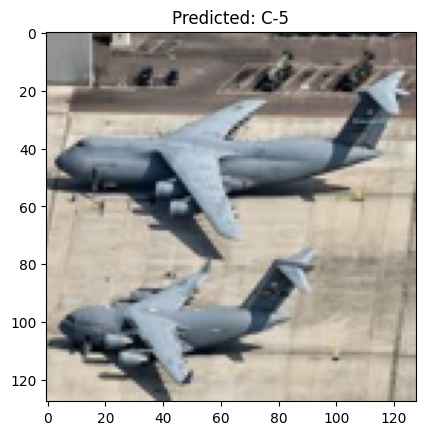

In [16]:
def predict_aircraft(model, img_path, image_size, aircraft_types):
    img = Image.open(img_path).convert('RGB')
    img = img.resize((image_size, image_size))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = aircraft_types[np.argmax(prediction)]
    print(f"Predicted Aircraft: {predicted_class}")
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.show()

# Example test image
model = tf.keras.models.load_model('/content/drive/MyDrive/mini_project/trained_aircraft_model.keras')
predict_aircraft(model, TEST_IMAGES_DIR + 'example.jpg', IMAGE_SIZE, aircraft_types)